In [1]:
!pip install yfinance mplfinance pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.9 MB/s eta 0:00:00


In [7]:
# pip install yfinance mplfinance pandas numpy matplotlib

import numpy as np
import pandas as pd
import yfinance as yf
import mplfinance as mpf
import matplotlib.pyplot as plt


def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def add_indicators(
    df: pd.DataFrame,
    bb_period: int = 20,
    bb_std: float = 2.0,
    rsi_period: int = 14,
    squeeze_lookback: int = 120,
    squeeze_percentile: float = 0.2,
) -> pd.DataFrame:
    df = df.copy()

    # Bollinger Bands
    df["MB"] = df["Close"].rolling(bb_period).mean()
    df["STD"] = df["Close"].rolling(bb_period).std(ddof=0)
    df["UB"] = df["MB"] + bb_std * df["STD"]
    df["LB"] = df["MB"] - bb_std * df["STD"]

    # BandWidth (%)
    df["BBW"] = (df["UB"] - df["LB"]) / df["MB"] * 100

    # RSI
    df["RSI"] = compute_rsi(df["Close"], period=rsi_period)

    # Squeeze threshold: rolling percentile
    df["BBW_Q"] = (
        df["BBW"]
        .rolling(squeeze_lookback)
        .apply(lambda x: np.nanpercentile(x, squeeze_percentile * 100), raw=True)
    )
    df["SQUEEZE"] = df["BBW"] <= df["BBW_Q"]

    # Candle / momentum helpers
    df["PrevClose"] = df["Close"].shift(1)
    df["PrevLow"] = df["Low"].shift(1)
    df["PrevHigh"] = df["High"].shift(1)

    # ---------------------------------------------------------
    # 1) Lower band touch + RSI oversold + bullish confirmation
    # ---------------------------------------------------------
    # 해석:
    # - 전일 또는 당일 저가가 하단밴드 아래/근처
    # - RSI <= 30
    # - 오늘 종가가 전일 종가보다 높음 (간단한 반등 확인)
    lower_touch = (df["Low"] <= df["LB"]) | (df["PrevLow"] <= df["LB"].shift(1))
    bullish_confirm = df["Close"] > df["PrevClose"]

    df["BUY_REBOUND"] = lower_touch & (df["RSI"] <= 30) & bullish_confirm

    # ---------------------------------------------------------
    # 2) Upper band touch + RSI overbought + bearish confirmation
    # ---------------------------------------------------------
    upper_touch = (df["High"] >= df["UB"]) | (df["PrevHigh"] >= df["UB"].shift(1))
    bearish_confirm = df["Close"] < df["PrevClose"]

    df["SELL_REVERSION"] = upper_touch & (df["RSI"] >= 70) & bearish_confirm

    # ---------------------------------------------------------
    # 3) Squeeze breakout + RSI confirmation
    # ---------------------------------------------------------
    # 직전 구간이 squeeze 상태였고,
    # 현재 캔들이 상단/하단 밴드를 돌파하며 RSI가 방향 확인
    prev_squeeze = df["SQUEEZE"].shift(1).fillna(False)

    df["BREAKOUT_UP"] = (
        prev_squeeze
        & (df["Close"] > df["UB"])
        & (df["RSI"] > 50)
    )

    df["BREAKOUT_DOWN"] = (
        prev_squeeze
        & (df["Close"] < df["LB"])
        & (df["RSI"] < 50)
    )

    return df


def make_marker_series(df: pd.DataFrame) -> dict:
    # 가격 패널에 표시할 마커 위치
    buy_marker = pd.Series(np.nan, index=df.index)
    sell_marker = pd.Series(np.nan, index=df.index)
    breakout_up_marker = pd.Series(np.nan, index=df.index)
    breakout_down_marker = pd.Series(np.nan, index=df.index)

    buy_marker[df["BUY_REBOUND"]] = df.loc[df["BUY_REBOUND"], "Low"] * 0.985
    sell_marker[df["SELL_REVERSION"]] = df.loc[df["SELL_REVERSION"], "High"] * 1.015
    breakout_up_marker[df["BREAKOUT_UP"]] = df.loc[df["BREAKOUT_UP"], "Low"] * 0.975
    breakout_down_marker[df["BREAKOUT_DOWN"]] = df.loc[df["BREAKOUT_DOWN"], "High"] * 1.025

    return {
        "buy_marker": buy_marker,
        "sell_marker": sell_marker,
        "breakout_up_marker": breakout_up_marker,
        "breakout_down_marker": breakout_down_marker,
    }


def plot_chart(
    ticker: str = "AAPL",
    period: str = "1y",
    interval: str = "1d",
    bb_period: int = 20,
    bb_std: float = 2.0,
    rsi_period: int = 14,
    volume: bool = True,
    save_path: str | None = None,
):
    # Yahoo Finance OHLCV 다운로드
    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=False,
        progress=False,
        group_by="column",
        multi_level_index=False,
    )

    if df.empty:
        raise ValueError(f"데이터를 가져오지 못했습니다: {ticker}")

    # 컬럼 정리
    expected_cols = ["Open", "High", "Low", "Close", "Volume"]
    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        raise ValueError(f"필수 컬럼이 없습니다: {missing}")

    df = df[expected_cols].dropna().copy()

    # 지표 계산
    df = add_indicators(
        df,
        bb_period=bb_period,
        bb_std=bb_std,
        rsi_period=rsi_period,
    )

    markers = make_marker_series(df)

    # RSI 수평선용 시리즈
    rsi_70 = pd.Series(70, index=df.index)
    rsi_50 = pd.Series(50, index=df.index)
    rsi_30 = pd.Series(30, index=df.index)

    addplots = [
        # Bollinger Bands
        mpf.make_addplot(df["UB"], panel=0, width=1),
        mpf.make_addplot(df["MB"], panel=0, width=1),
        mpf.make_addplot(df["LB"], panel=0, width=1),

        # Buy / Sell markers
        mpf.make_addplot(
            markers["buy_marker"],
            panel=0,
            type="scatter",
            marker="^",
            markersize=120,
        ),
        mpf.make_addplot(
            markers["sell_marker"],
            panel=0,
            type="scatter",
            marker="v",
            markersize=120,
        ),
        mpf.make_addplot(
            markers["breakout_up_marker"],
            panel=0,
            type="scatter",
            marker="*",
            markersize=180,
        ),
        mpf.make_addplot(
            markers["breakout_down_marker"],
            panel=0,
            type="scatter",
            marker="X",
            markersize=140,
        ),

        # RSI panel
        mpf.make_addplot(df["RSI"], panel=2, ylabel="RSI", width=1),
        mpf.make_addplot(rsi_70, panel=2, width=0.8, linestyle="--"),
        mpf.make_addplot(rsi_50, panel=2, width=0.8, linestyle=":"),
        mpf.make_addplot(rsi_30, panel=2, width=0.8, linestyle="--"),
    ]

    title = (
        f"{ticker} | Bollinger Bands({bb_period}, {bb_std}) + RSI({rsi_period})\n"
        f"^ Buy Rebound | v Sell Reversion | * Breakout Up | X Breakout Down"
    )

    fig, axes = mpf.plot(
        df,
        type="candle",
        style="yahoo",
        addplot=addplots,
        volume=volume,
        panel_ratios=(6, 2, 2) if volume else (8, 3),
        figscale=1.2,
        figratio=(16, 9),
        title=title,
        returnfig=True,
        tight_layout=True,
    )

    # 신호 개수 출력
    n_buy = int(df["BUY_REBOUND"].sum())
    n_sell = int(df["SELL_REVERSION"].sum())
    n_bu = int(df["BREAKOUT_UP"].sum())
    n_bd = int(df["BREAKOUT_DOWN"].sum())

    print(f"[{ticker}]")
    print(f"BUY_REBOUND      : {n_buy}")
    print(f"SELL_REVERSION   : {n_sell}")
    print(f"BREAKOUT_UP      : {n_bu}")
    print(f"BREAKOUT_DOWN    : {n_bd}")

    # 최근 신호 몇 개 보기
    signal_cols = ["BUY_REBOUND", "SELL_REVERSION", "BREAKOUT_UP", "BREAKOUT_DOWN"]
    recent_signals = df.loc[df[signal_cols].any(axis=1), ["Open", "High", "Low", "Close", "Volume", "RSI"] + signal_cols]
    if not recent_signals.empty:
        print("\n최근 신호:")
        print(recent_signals.tail(15))

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"\n차트 저장 완료: {save_path}")

    plt.show()

    return df


# if __name__ == "__main__":
    # 예시 1: 애플
    plot_chart(
        ticker="AAPL",
        period="1y",
        interval="1d",
        bb_period=20,
        bb_std=2.0,
        rsi_period=14,
        volume=True,
        save_path="aapl_bollinger_rsi.png",
    )

    # 예시 2: 삼성전자 (Yahoo Finance 티커 예시: 005930.KS)
    # plot_chart(
    #     ticker="005930.KS",
    #     period="1y",
    #     interval="1d",
    #     save_path="samsung_bollinger_rsi.png",
    # )

/tmp/ipykernel_294/3419634938.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_squeeze = df["SQUEEZE"].shift(1).fillna(False)
/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


[RXRX]
BUY_REBOUND      : 1
SELL_REVERSION   : 7
BREAKOUT_UP      : 16
BREAKOUT_DOWN    : 11

최근 신호:
             Open   High    Low  Close    Volume        RSI  BUY_REBOUND  \
Date                                                                       
2024-11-11  7.500  8.490  7.230  7.840  15577600  68.381374        False   
2025-03-31  5.495  5.510  5.190  5.290  17981300  33.283070        False   
2025-06-04  4.450  5.080  4.410  4.910  46074900  54.916095        False   
2025-06-06  4.720  5.520  4.705  5.490  60323000  61.380519        False   
2025-07-09  5.460  5.770  5.430  5.590  34721700  59.223622        False   
2025-07-10  5.710  5.879  5.570  5.715  28683900  60.995224        False   
2025-07-18  5.650  6.225  5.570  5.840  53043400  61.592297        False   
2025-07-21  6.110  7.150  6.030  6.400  75466000  68.438967        False   
2025-08-20  5.010  5.090  4.730  4.770  24970700  35.528644        False   
2025-10-01  4.825  5.230  4.803  5.100  43900000  55.989815    

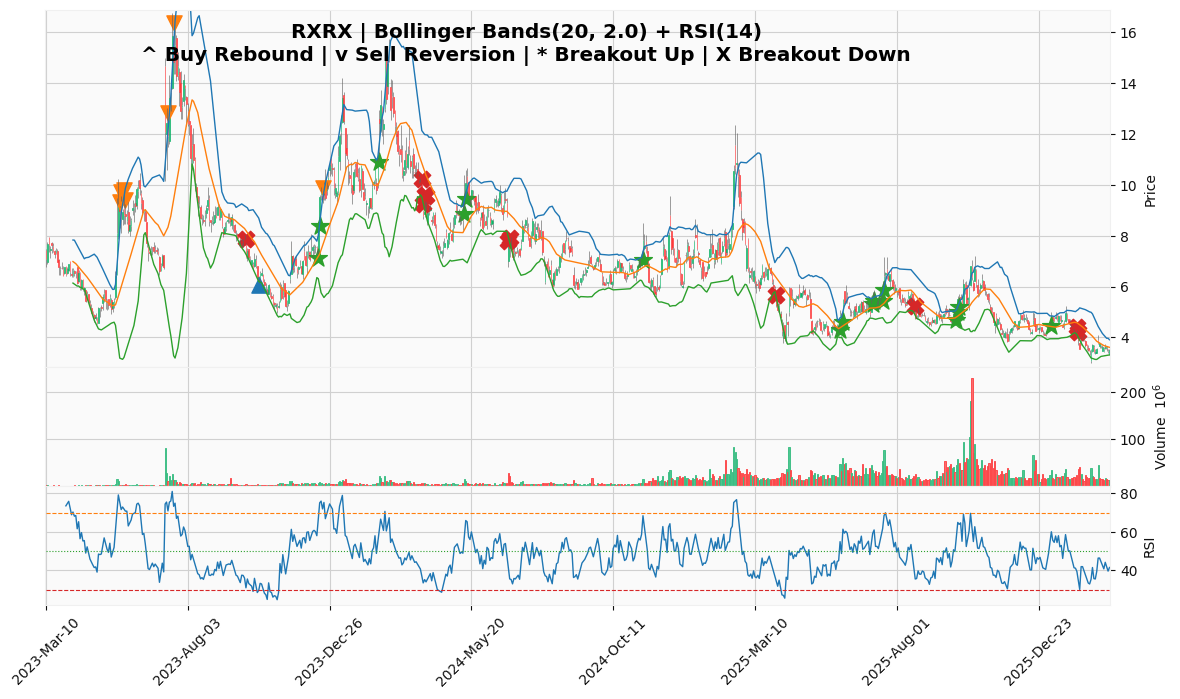

,Open,High,Low,Close,Volume,MB,STD,UB,LB,BBW,RSI,BBW_Q,SQUEEZE,PrevClose,PrevLow,PrevHigh,BUY_REBOUND,SELL_REVERSION,BREAKOUT_UP,BREAKOUT_DOWN
Date,,,,,,,,,,,,,,,,,,,,
2023-03-10,7.44,7.48,6.755,7.07,1862600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,False,False,False,False
2023-03-13,6.98,7.75,6.870,7.67,1486600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,7.07,6.755,7.48,False,False,False,False
2023-03-14,7.95,7.95,7.370,7.63,1046900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,7.67,6.870,7.75,False,False,False,False
2023-03-15,7.43,7.60,7.130,7.48,1146800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,7.63,7.370,7.95,False,False,False,False
2023-03-16,7.71,7.75,7.330,7.65,916600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,7.48,7.130,7.60,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03,3.46,3.61,3.440,3.54,12569200,3.6800,0.196087,4.072173,3.287827,21.313772,40.792378,20.232633,False,3.63,3.460,3.71,False,False,False,False
2026-03-04,3.60,3.76,3.530,3.64,16256000,3.6570,0.170824,3.998649,3.315351,18.684656,44.196751,20.196779,True,3.54,3.440,3.61,False,False,False,False
2026-03-05,3.55,3.68,3.460,3.54,14054500,3.6390,0.163061,3.965123,3.312877,17.923751,41.619587,19.972749,True,3.64,3.530,3.76,False,False,False,False


In [8]:
plot_chart(
    ticker="RXRX",
    period="3y",
    interval="1d",
    bb_period=20,
    bb_std=2.0,
    rsi_period=14,
    volume=True,
    save_path="rxrx_bollinger_rsi.png",
)

아래 표는 코드에서 생성된 **DataFrame 변수들을 한눈에 정리한 것**입니다.

| 변수             | 분류     | 계산 / 값               | 의미              |
| -------------- | ------ | -------------------- | --------------- |
| Open           | 시장 데이터 | 시가                   | 해당 기간 시작 가격     |
| High           | 시장 데이터 | 고가                   | 해당 기간 최고 가격     |
| Low            | 시장 데이터 | 저가                   | 해당 기간 최저 가격     |
| Close          | 시장 데이터 | 종가                   | 해당 기간 마지막 거래 가격 |
| Volume         | 시장 데이터 | 거래량                  | 해당 기간 거래된 주식 수  |
| MB             | 볼린저밴드  | 20일 이동평균             | 가격의 평균 중심선      |
| STD            | 볼린저밴드  | 20일 표준편차             | 가격 변동성          |
| UB             | 볼린저밴드  | MB + 2 × STD         | 상단 밴드           |
| LB             | 볼린저밴드  | MB − 2 × STD         | 하단 밴드           |
| BBW            | 변동성 지표 | (UB − LB) / MB × 100 | 볼린저 밴드 폭        |
| RSI            | 모멘텀 지표 | 0 ~ 100              | 상대강도지수          |
| BBW_Q          | 스퀴즈 기준 | 최근 120일 BBW 하위 20%   | 스퀴즈 기준값         |
| SQUEEZE        | 상태 변수  | BBW ≤ BBW_Q          | 변동성 축소 여부       |
| PrevClose      | 이전 데이터 | 전일 종가                | 이전 캔들 종가        |
| PrevLow        | 이전 데이터 | 전일 저가                | 이전 캔들 저가        |
| PrevHigh       | 이전 데이터 | 전일 고가                | 이전 캔들 고가        |
| BUY_REBOUND    | 전략 신호  | True / False         | 반등 매수 신호        |
| SELL_REVERSION | 전략 신호  | True / False         | 되돌림 매도 신호       |
| BREAKOUT_UP    | 전략 신호  | True / False         | 상승 돌파 신호        |
| BREAKOUT_DOWN  | 전략 신호  | True / False         | 하락 돌파 신호        |

---

## 설명

### 1️⃣ 시장 데이터 (OHLCV)

* **Open, High, Low, Close, Volume**
* 주식 시장에서 기본적으로 제공되는 데이터입니다.
* 차트의 **캔들스틱**은 이 값들로 만들어집니다.

예시 해석

* Open = 100
* High = 105
* Low = 98
* Close = 103

→ 해당 기간 동안 **98 ~ 105 사이에서 거래되고 103에 마감**

---

### 2️⃣ 볼린저 밴드 지표

볼린저 밴드는 Bollinger Bands 입니다.

구성 요소

* **MB (Middle Band)**

  * 20일 이동평균
  * 가격의 중심선

* **UB (Upper Band)**

  * 평균 + 2 표준편차
  * 가격 상단 범위

* **LB (Lower Band)**

  * 평균 − 2 표준편차
  * 가격 하단 범위

* **STD**

  * 가격 변동성

---

### 3️⃣ 변동성 지표

**BBW (Bollinger Band Width)**

```
BBW = (UB - LB) / MB × 100
```

의미

| BBW 값 | 시장 상태  |
| ----- | ------ |
| 작음    | 변동성 낮음 |
| 큼     | 변동성 높음 |

BBW가 매우 작으면 **스퀴즈(Squeeze)** 상태가 됩니다.

---

### 4️⃣ RSI 모멘텀 지표

RSI는 Relative Strength Index 입니다.

값 범위

```
0 ~ 100
```

해석 기준

| RSI   | 의미  |
| ----- | --- |
| 70 이상 | 과매수 |
| 30 이하 | 과매도 |
| 50    | 중립  |

---

### 5️⃣ 스퀴즈 관련 변수

**BBW_Q**

* 최근 120일 BBW 중 **하위 20% 값**

**SQUEEZE**

```
BBW ≤ BBW_Q
```

이면

→ **변동성 매우 낮은 상태**

이 상태 이후에는

➡ **큰 가격 움직임이 발생할 가능성이 높습니다**

---

### 6️⃣ 이전 캔들 데이터

| 변수        | 의미    |
| --------- | ----- |
| PrevClose | 전일 종가 |
| PrevLow   | 전일 저가 |
| PrevHigh  | 전일 고가 |

이 값들은 **가격 반전 확인용**으로 사용됩니다.

예

```
오늘 Close > PrevClose
```

→ 상승 확인

---

### 7️⃣ 전략 신호 변수

#### BUY_REBOUND

조건

* 하단 볼린저 밴드 터치
* RSI ≤ 30
* 가격 반등

의미

→ **과매도 후 반등 매수 신호**

---

#### SELL_REVERSION

조건

* 상단 밴드 터치
* RSI ≥ 70
* 하락 확인

의미

→ **과열 후 되돌림 매도 신호**

---

#### BREAKOUT_UP

조건

* 직전 스퀴즈
* 상단 밴드 돌파
* RSI > 50

의미

→ **상승 추세 시작 가능**

---

#### BREAKOUT_DOWN

조건

* 직전 스퀴즈
* 하단 밴드 이탈
* RSI < 50

의미

→ **하락 추세 시작 가능**

---

💡 **핵심 포인트**

이 DataFrame은 이미 **퀀트 트레이딩 분석용 데이터셋**입니다.

즉 다음 같은 분석을 바로 할 수 있습니다.

* 전략 **승률**
* **누적 수익률**
* **최대 손실 (MDD)**
* **Sharpe ratio**
* **파라미터 최적화**

---

원하시면 다음 단계로 **지금 만든 코드에 “자동 백테스트 기능”을 추가하는 코드**도 만들어 드릴게요.
이 단계부터는 **실제 퀀트 트레이딩 수준**으로 들어갑니다. 📈
